# Import Packages

In [469]:
import scvi
import os
import numpy as np
import pandas as pd
import datetime
from pathlib import Path
import scanpy as sc
import re
from pprint import pprint

from natsort import natsorted

from sklearn import metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import umap

from tqdm.auto import tqdm, trange
import anndata as ad
from copy import deepcopy


from scipy import stats, linalg

import matplotlib as mpl
import matplotlib.pyplot as plt
#import cmocean
import seaborn as sns
from mpl_toolkits import mplot3d
%matplotlib inline  

sc.settings.verbosity = 4

# Read in data

In [470]:
adata = sc.read("/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/ent_Goldstein_merge.h5ad")


In [471]:
meta_data = pd.read_csv('/sc/arion/projects/roussp01a/liting/Olf/data/ent_goldstein_merge_cca.metadata.csv', index_col=0)

adata = adata[meta_data.index]
adata.obs["N_types_stage"]= meta_data.loc[adata.obs.index,'cca_N_types_stage'] 

/tmp/ipykernel_1185744/2013925915.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["N_types_stage"]= meta_data.loc[adata.obs.index,'cca_N_types_stage']


In [472]:
ensg=pd.read_table('/sc/arion/projects/roussp01a/liting/Olf/Homo.GRCh38.104.txt',index_col=0)
chr_autos = [format(x, '1d') for x in range(1,23)]
ensg_pa = ensg.loc[(ensg.chr.isin(chr_autos)) & (ensg.gene_biotype=='protein_coding'),:]
adata = adata[:,list(set(adata.var_names) & set(ensg_pa.gene_name))]

adata=adata[adata.obs.donor_name!='GSM4142870_Patient1']
adata.obs.donor_name=adata.obs.donor_name.astype(str)
adata.obs.donor_name[adata.obs.dataset=='ENT']='ENT'


adata.X=adata.layers["counts"]
#adata = nn_adata
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=5)
#sc.pp.downsample_counts(adata, counts_per_cell=2000)

# mitochondrial genes, "MT-" for human, 
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")


sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

/sc/arion/projects/roussp01a/liting/software/conda/scvi/lib/python3.12/site-packages/pandas/core/generic.py:6351: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self[name] = value
/tmp/ipykernel_1185744/2238879395.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.o

filtered out 1088 genes that are detected in less than 5 cells
normalizing counts per cell
    finished (0:00:00)


# Fit scvi model

In [473]:
def scvi_osn(batch, n_hvg,i):

    sc.pp.highly_variable_genes(
        adata,
        layer="counts",
        n_top_genes=n_hvg,
        min_mean=0.0125,
        max_mean=3,
        batch_key=batch,
        min_disp=1,
        flavor="seurat_v3",
    )
    
    adata_query = adata[:, adata.var.highly_variable].copy()

    scvi.model.SCVI.setup_anndata(
        adata_query,
        layer="counts",
        batch_key=batch#"donor_name",

    )
    model = scvi.model.SCVI(adata_query)
    train_kwargs = dict(
        early_stopping=True,
        enable_model_summary=True,
        enable_progress_bar=True,
        enable_checkpointing=True,
        max_epochs=500
    )
    model.train(**train_kwargs)
    latent = model.get_latent_representation()
    adata.obsm["X_scVI"] = latent
    sc.pp.neighbors(adata, use_rep="X_scVI")
    sc.tl.umap(adata, min_dist=0.3)
    sc.tl.leiden(adata, key_added="leiden_scVI", resolution=0.5)
    sc.pl.umap(adata, color=["N_types_stage", "dataset"],  s=30,  vmax="p99.99", save=f'ent_goldstein_scvi_osn_{i}_{n_hvg}.pdf')#(batch='', n_hvg=3000)

    return(adata)




extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 240/500:  48%|████▊     | 240/500 [00:34<00:37,  7.00it/s, v_num=1, train_loss=1.22e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1270.776. Signaling Trainer to stop.
computing neighbors
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 95%|█████████▌| 476/500 [00:01<00:00, 387.92it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:01<00:00, 389.08it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering


    finished: found 5 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


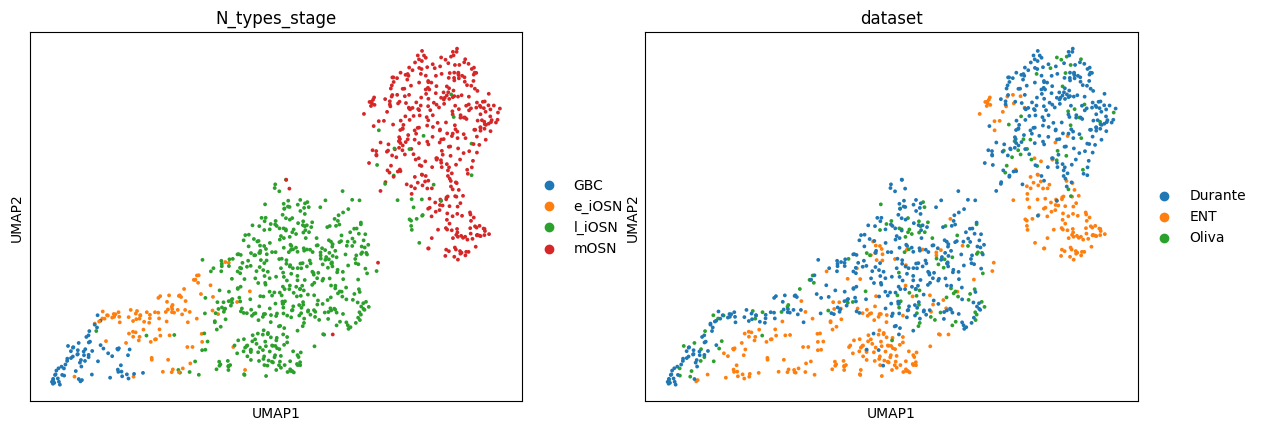

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 225/500:  45%|████▌     | 225/500 [00:35<00:43,  6.32it/s, v_num=1, train_loss=1.66e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1755.421. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  9%|▊         | 43/500 [00:00<00:01, 419.93it/s]

	completed  0  /  500 epochs
	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


 96%|█████████▌| 479/500 [00:01<00:00, 388.92it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:01<00:00, 390.26it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


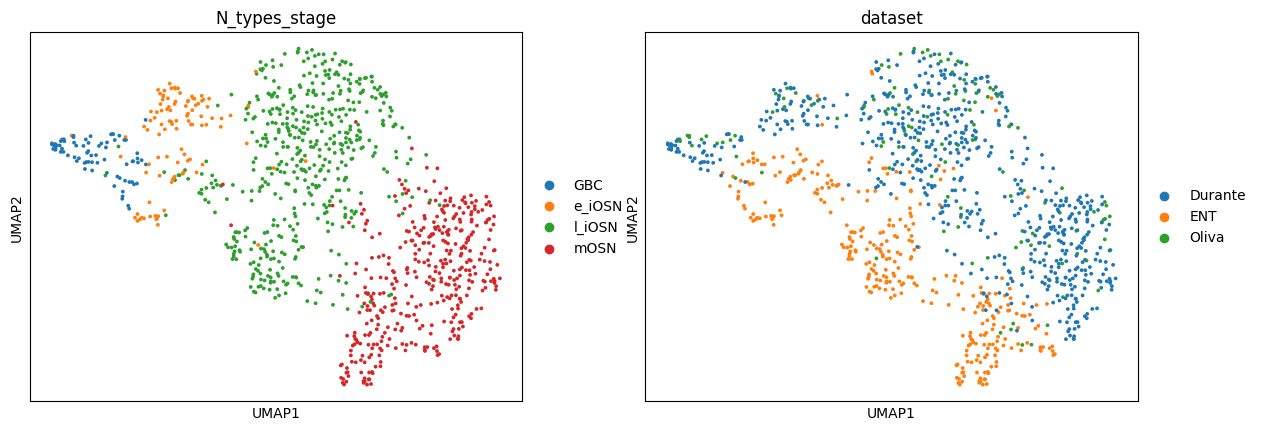

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 214/500:  43%|████▎     | 214/500 [00:30<00:40,  7.12it/s, v_num=1, train_loss=1.22e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1358.377. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 83%|████████▎ | 413/500 [00:00<00:00, 500.38it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 502.63it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering


    finished: found 5 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


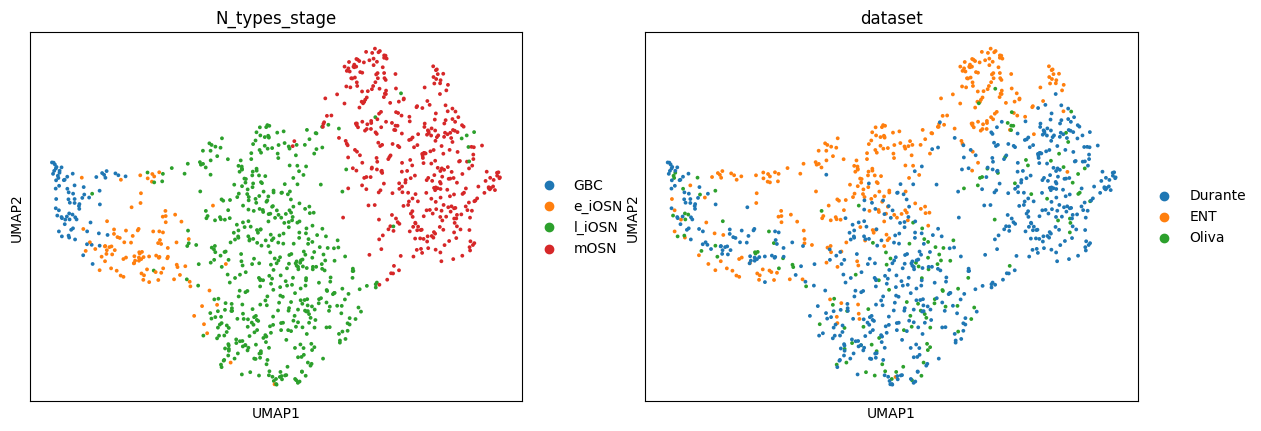

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 230/500:  46%|████▌     | 230/500 [00:34<00:40,  6.64it/s, v_num=1, train_loss=1.65e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1930.265. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

	completed  350  /  500 epochs


 90%|████████▉ | 448/500 [00:00<00:00, 482.37it/s]

	completed  400  /  500 epochs
	completed  450  /  500 epochs


100%|██████████| 500/500 [00:01<00:00, 484.43it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering
    finished: found 5 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


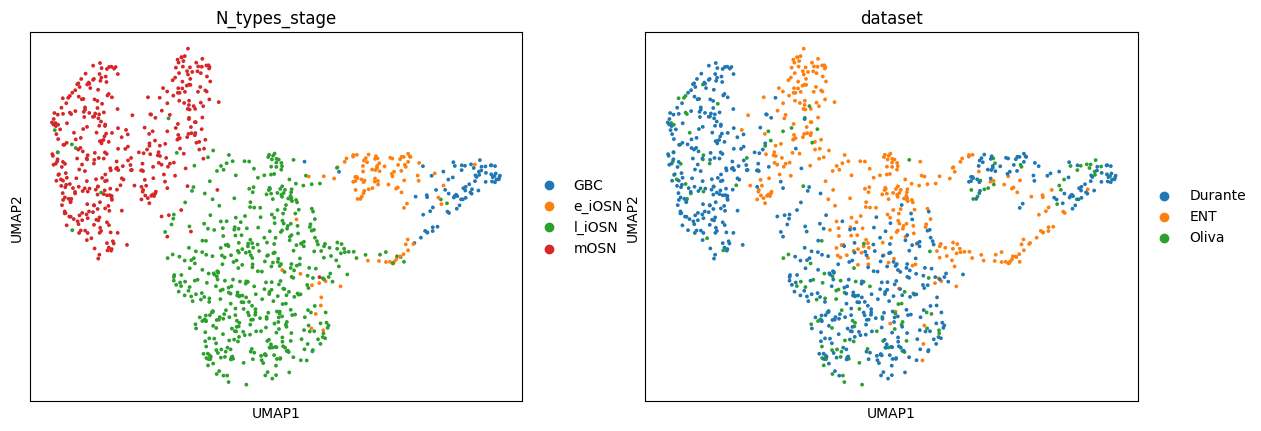

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 255/500:  51%|█████     | 255/500 [00:33<00:32,  7.56it/s, v_num=1, train_loss=1.21e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1293.650. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

	completed  300  /  500 epochs
	completed  350  /  500 epochs


 90%|████████▉ | 449/500 [00:00<00:00, 487.96it/s]

	completed  400  /  500 epochs


100%|██████████| 500/500 [00:01<00:00, 489.04it/s]

	completed  450  /  500 epochs
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering
    finished: found 4 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


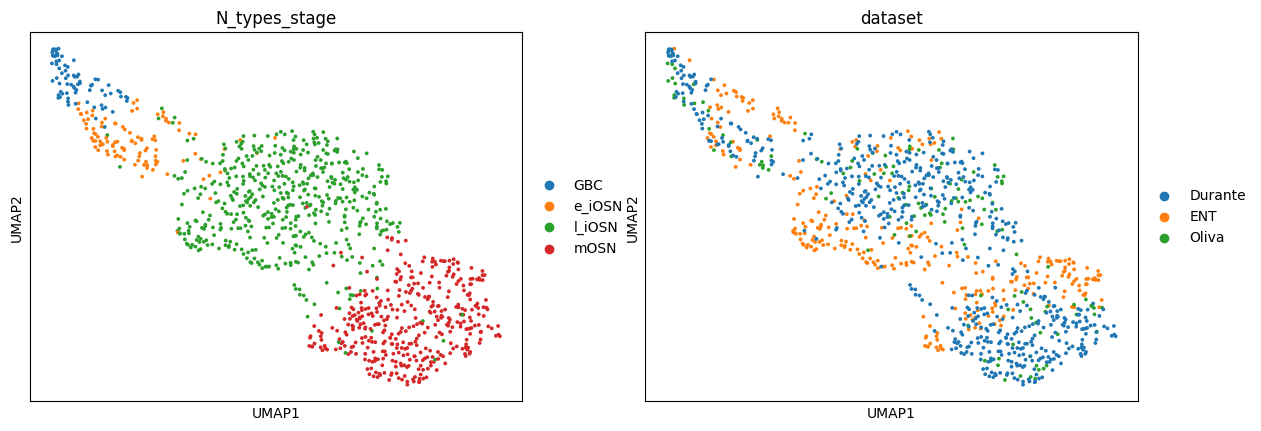

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 198/500:  40%|███▉      | 198/500 [00:31<00:47,  6.36it/s, v_num=1, train_loss=1.66e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1927.819. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 83%|████████▎ | 415/500 [00:00<00:00, 502.77it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 504.68it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering


    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


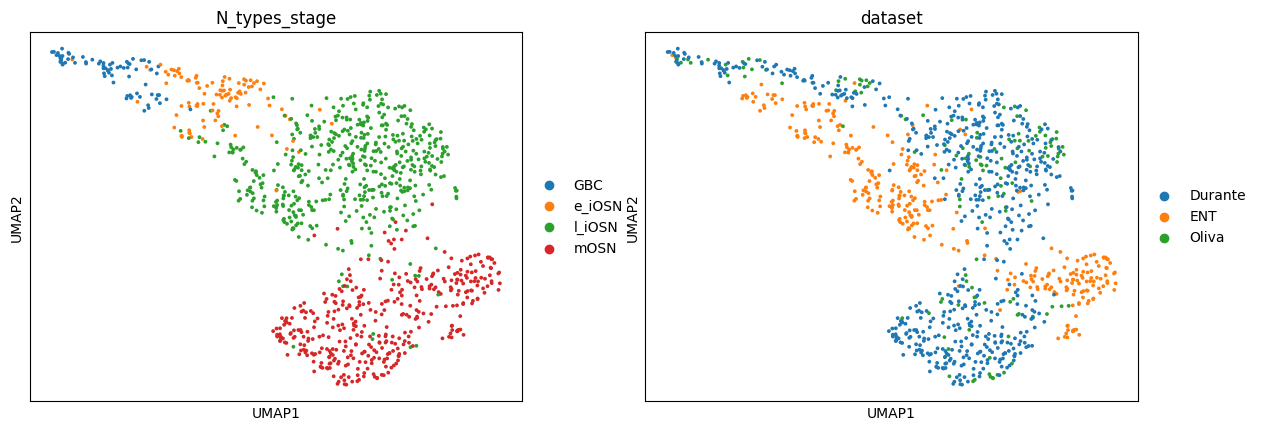

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 258/500:  52%|█████▏    | 258/500 [00:34<00:32,  7.55it/s, v_num=1, train_loss=1.21e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1304.236. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

	completed  300  /  500 epochs
	completed  350  /  500 epochs


 80%|████████  | 400/500 [00:00<00:00, 485.86it/s]

	completed  400  /  500 epochs


100%|██████████| 500/500 [00:01<00:00, 487.80it/s]

	completed  450  /  500 epochs
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering
    finished: found 4 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


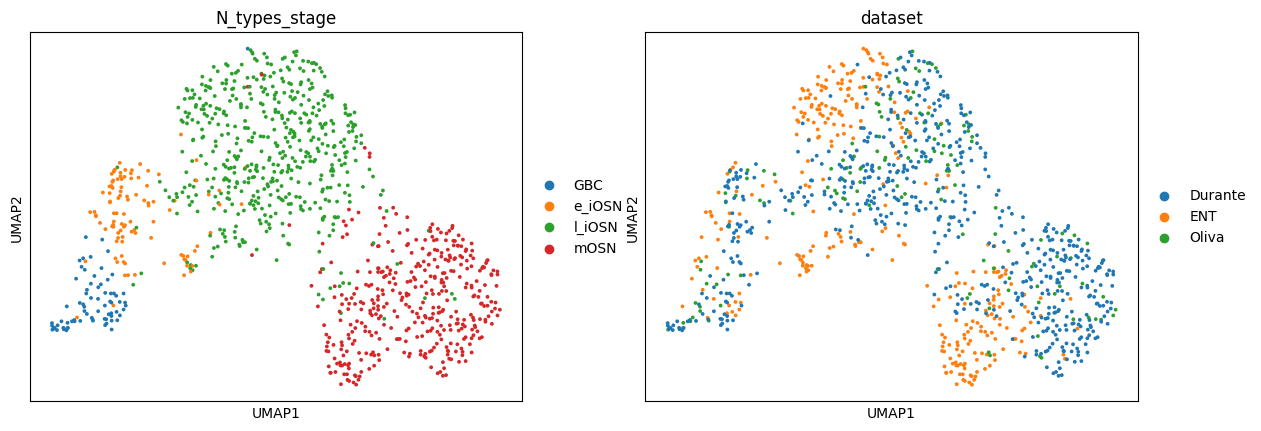

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 194/500:  39%|███▉      | 194/500 [00:29<00:45,  6.68it/s, v_num=1, train_loss=1.69e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1772.301. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

	completed  400  /  500 epochs


 83%|████████▎ | 416/500 [00:00<00:00, 505.65it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 508.14it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:00)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


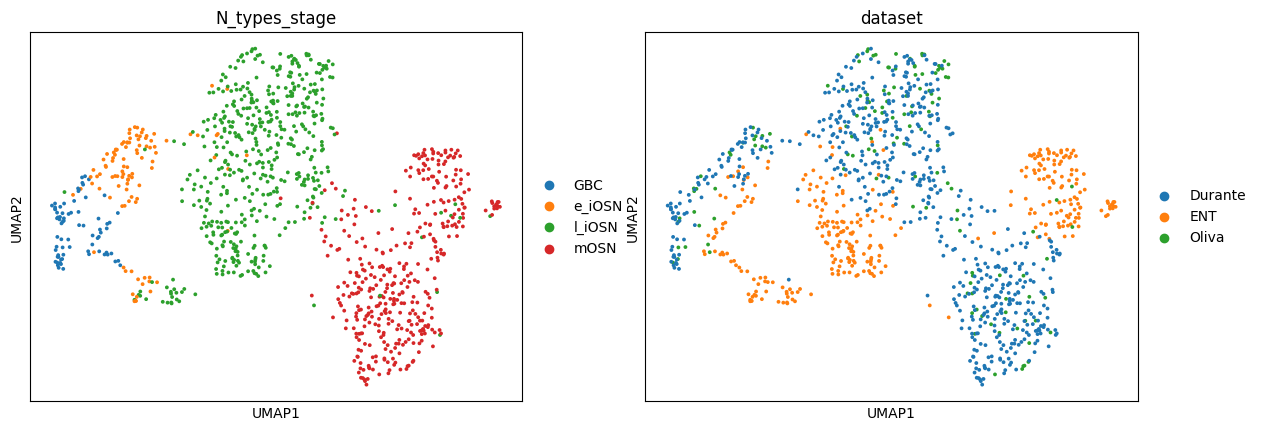

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 218/500:  44%|████▎     | 218/500 [00:29<00:37,  7.48it/s, v_num=1, train_loss=1.22e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1424.078. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 83%|████████▎ | 415/500 [00:00<00:00, 501.76it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 504.18it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering


    finished: found 4 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


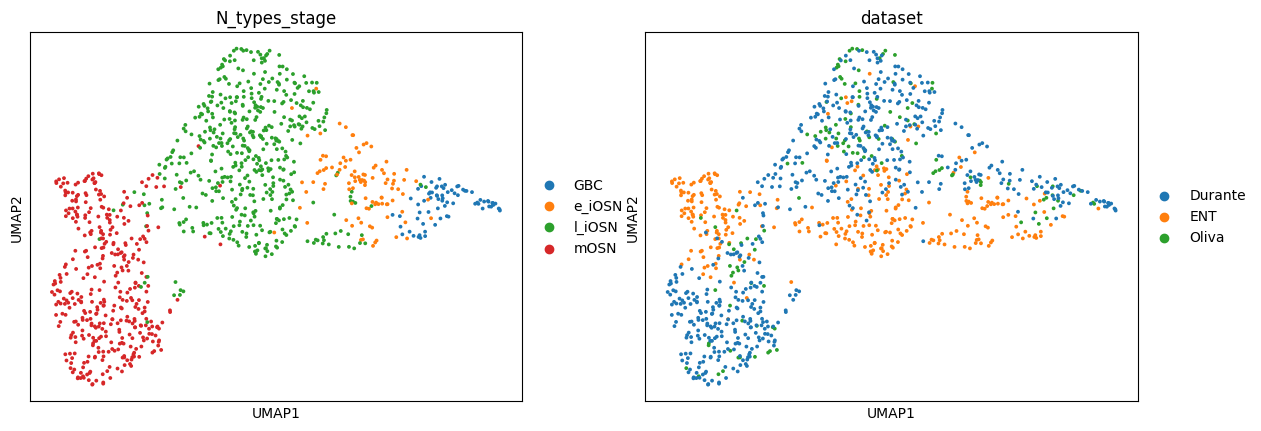

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 213/500:  43%|████▎     | 213/500 [00:31<00:42,  6.75it/s, v_num=1, train_loss=1.65e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1997.715. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 83%|████████▎ | 416/500 [00:00<00:00, 507.22it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 509.43it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:00)
running Leiden clustering


    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


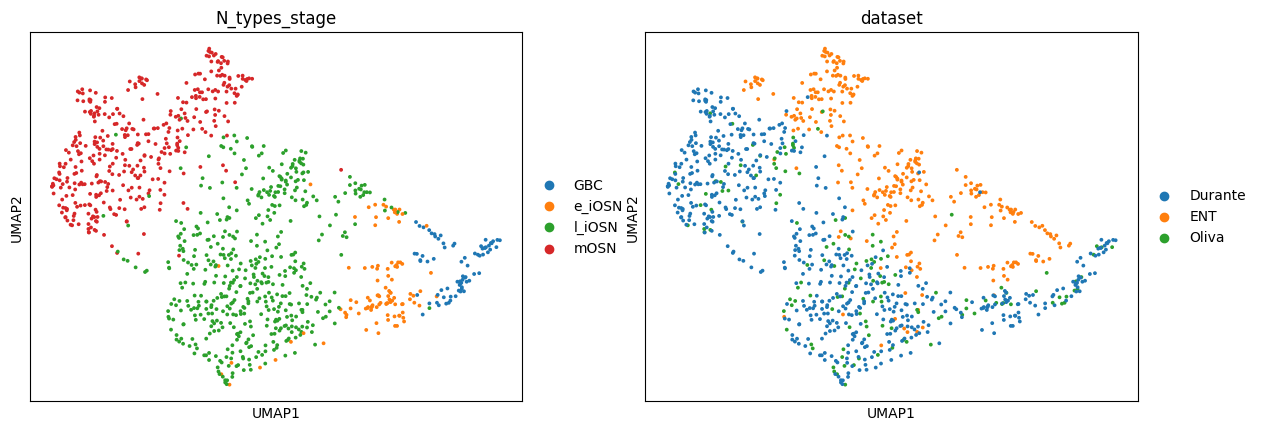

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 204/500:  41%|████      | 204/500 [00:27<00:39,  7.51it/s, v_num=1, train_loss=1.24e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1268.965. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 83%|████████▎ | 415/500 [00:00<00:00, 502.27it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 504.29it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering


    finished: found 5 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


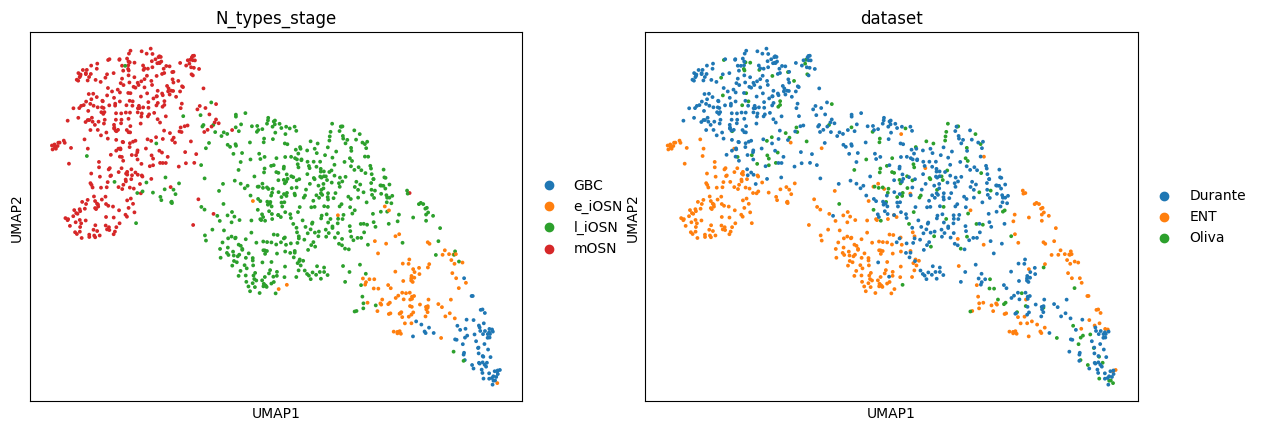

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 199/500:  40%|███▉      | 199/500 [00:29<00:45,  6.67it/s, v_num=1, train_loss=1.67e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1898.244. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 83%|████████▎ | 414/500 [00:00<00:00, 501.22it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 503.22it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering


    finished: found 5 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


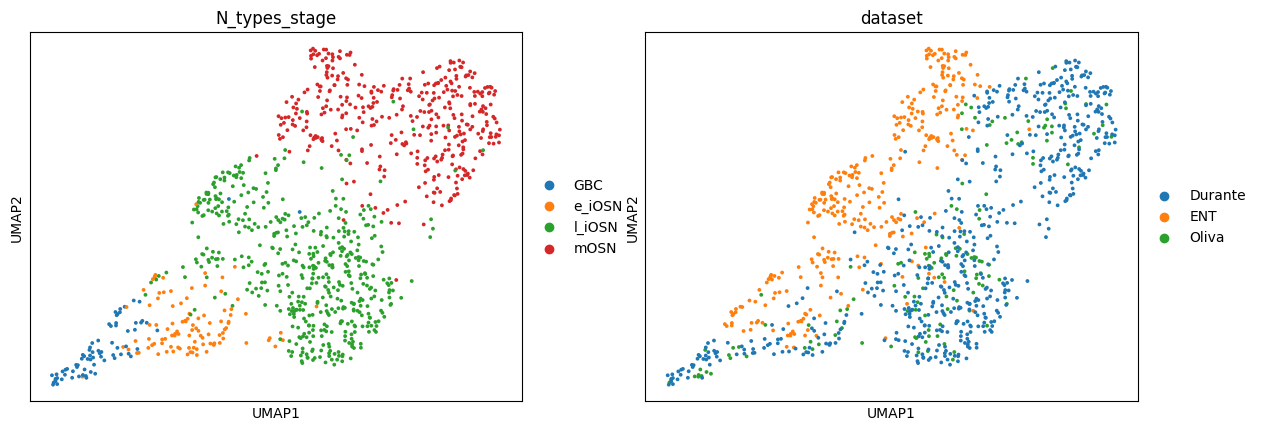

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 213/500:  43%|████▎     | 213/500 [00:27<00:37,  7.69it/s, v_num=1, train_loss=1.23e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1354.292. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 83%|████████▎ | 416/500 [00:00<00:00, 507.33it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 509.43it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:00)
running Leiden clustering


    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


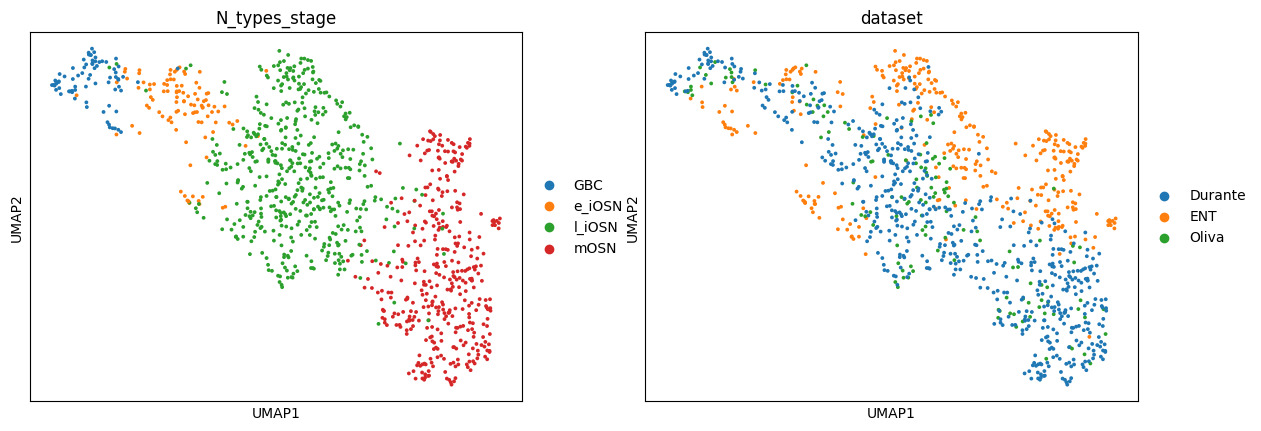

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 187/500:  37%|███▋      | 187/500 [00:27<00:46,  6.68it/s, v_num=1, train_loss=1.69e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1786.643. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 83%|████████▎ | 413/500 [00:00<00:00, 498.18it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 501.19it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering


    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


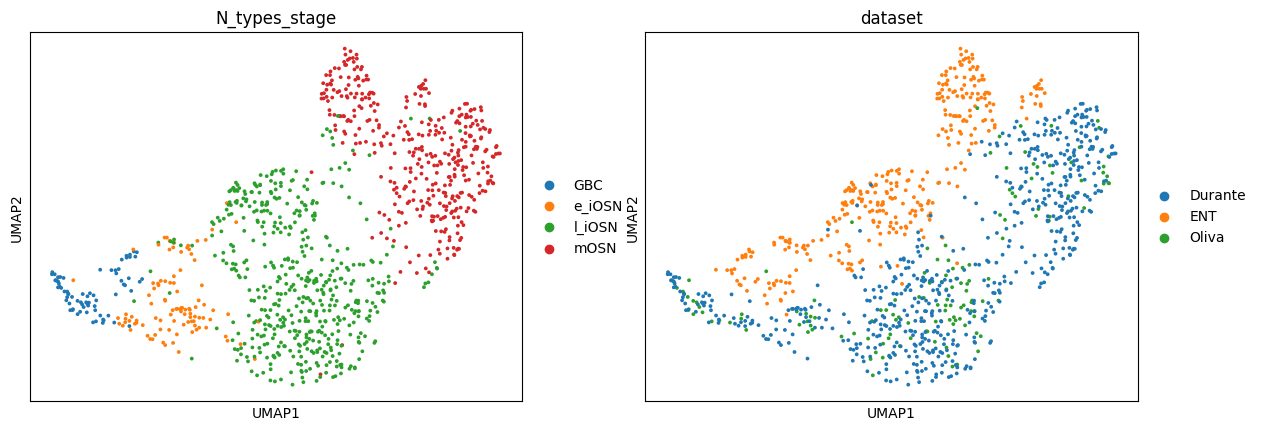

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 237/500:  47%|████▋     | 237/500 [00:31<00:34,  7.64it/s, v_num=1, train_loss=1.22e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1246.293. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 83%|████████▎ | 416/500 [00:00<00:00, 505.54it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 507.63it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:00)
running Leiden clustering


    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


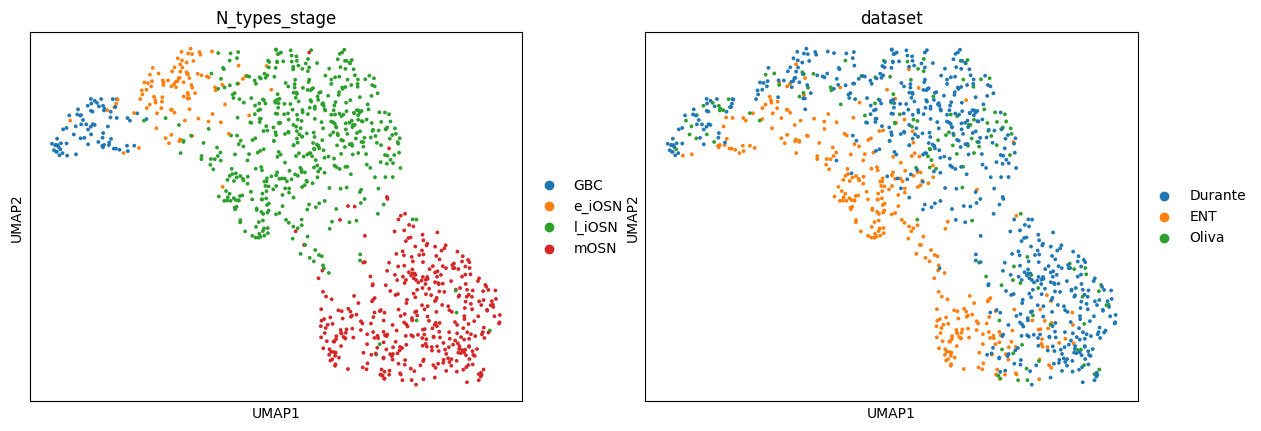

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 207/500:  41%|████▏     | 207/500 [00:31<00:44,  6.63it/s, v_num=1, train_loss=1.68e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1800.192. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

	completed  350  /  500 epochs


 90%|████████▉ | 448/500 [00:00<00:00, 484.04it/s]

	completed  400  /  500 epochs
	completed  450  /  500 epochs


100%|██████████| 500/500 [00:01<00:00, 485.79it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


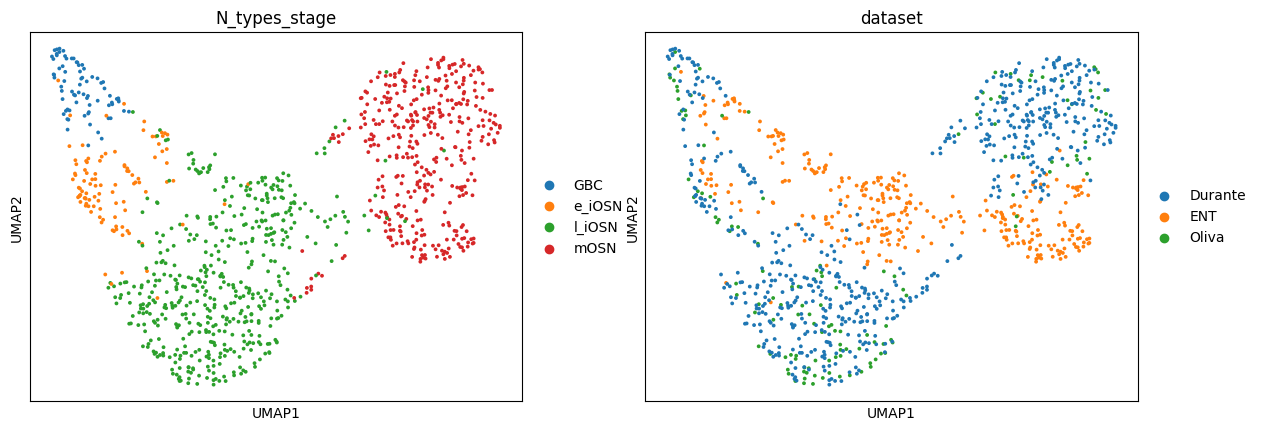

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 199/500:  40%|███▉      | 199/500 [00:27<00:41,  7.34it/s, v_num=1, train_loss=1.23e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1320.033. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 82%|████████▏ | 410/500 [00:00<00:00, 498.75it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:00<00:00, 501.07it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering


    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


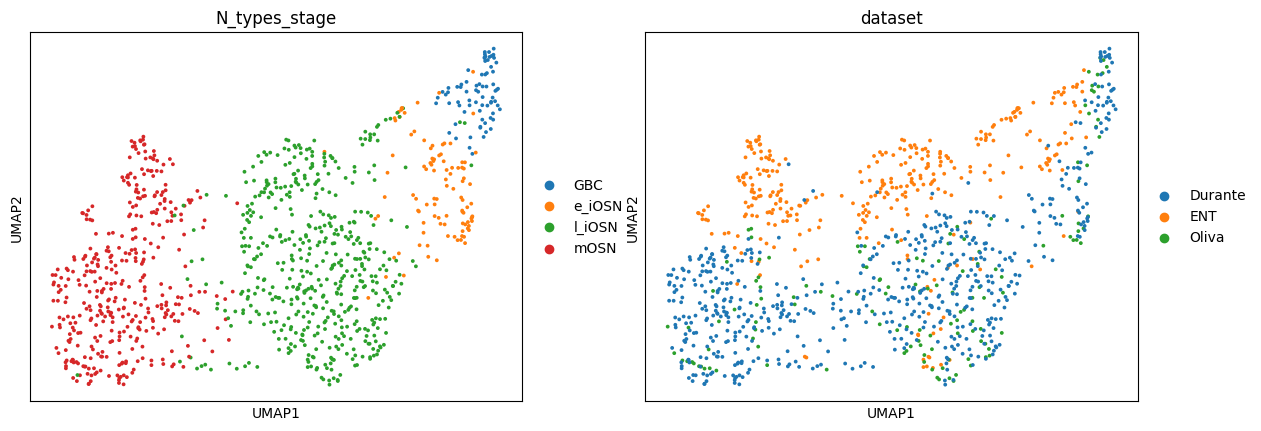

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 200/500:  40%|████      | 200/500 [00:30<00:45,  6.56it/s, v_num=1, train_loss=1.67e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1868.956. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

 81%|████████  | 406/500 [00:00<00:00, 482.91it/s]

	completed  400  /  500 epochs
	completed  450  /  500 epochs


100%|██████████| 500/500 [00:01<00:00, 481.26it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering


    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


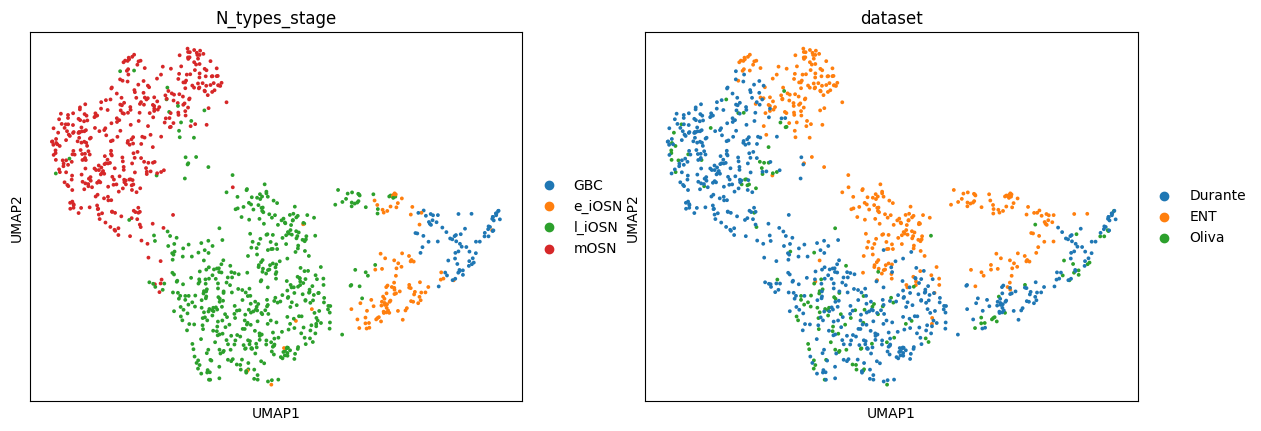

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.3 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.176     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 211/500:  42%|████▏     | 211/500 [00:27<00:37,  7.70it/s, v_num=1, train_loss=1.22e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1408.065. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

	completed  350  /  500 epochs
	completed  400  /  500 epochs


 89%|████████▉ | 447/500 [00:00<00:00, 481.87it/s]

	completed  450  /  500 epochs


100%|██████████| 500/500 [00:01<00:00, 483.29it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering
    finished: found 5 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


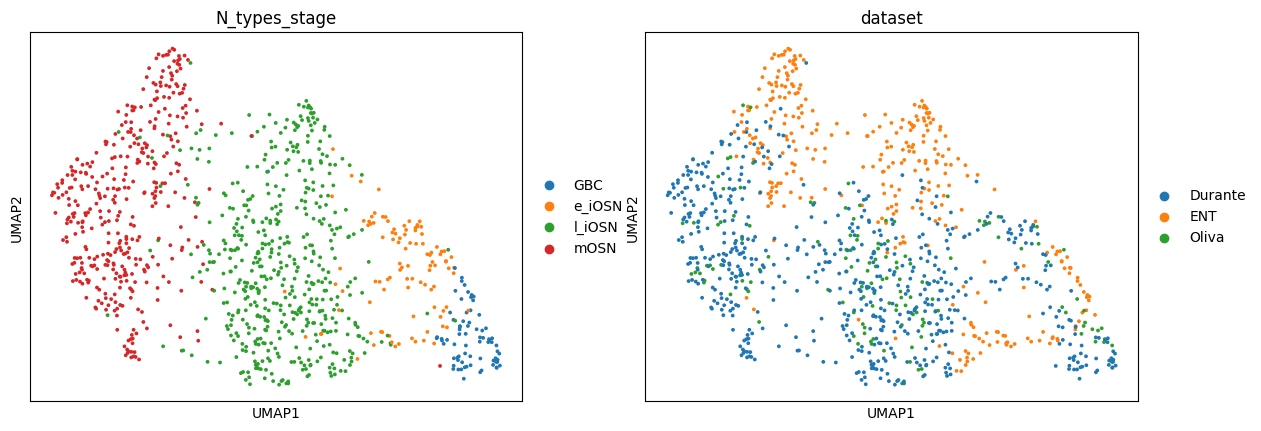

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type                | Params | Mode 
----------------------------------------------------------------
0 | module          | VAE                 | 1.9 M  | train
1 | elbo_train      | CompositionalMetric | 0      | train
2 | rec_loss_train  | ElboMetric          | 0      | train
3 | kl_local_train  | ElboMetric          | 0      | train
4 | kl_global_train | ElboMetric          | 0      | train
5 | elbo_val        | CompositionalMetric | 0      | train
6 | rec_loss_val    | ElboMetric          | 0      | train
7 | kl_local_val    | ElboMetric          | 0      | train
8 | kl_global_val   | ElboMetric          | 0      | train
----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.752     Total estimated model params size (MB)
45        Modules in train mode
0     

Epoch 198/500:  40%|███▉      | 198/500 [00:29<00:45,  6.61it/s, v_num=1, train_loss=1.67e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1860.789. Signaling Trainer to stop.
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs


...

	completed  300  /  500 epochs
	completed  350  /  500 epochs


 79%|███████▉  | 396/500 [00:00<00:00, 479.09it/s]

	completed  400  /  500 epochs


100%|██████████| 500/500 [00:01<00:00, 481.14it/s]

	completed  450  /  500 epochs
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden_scVI', the cluster labels (adata.obs, categorical) (0:00:00)


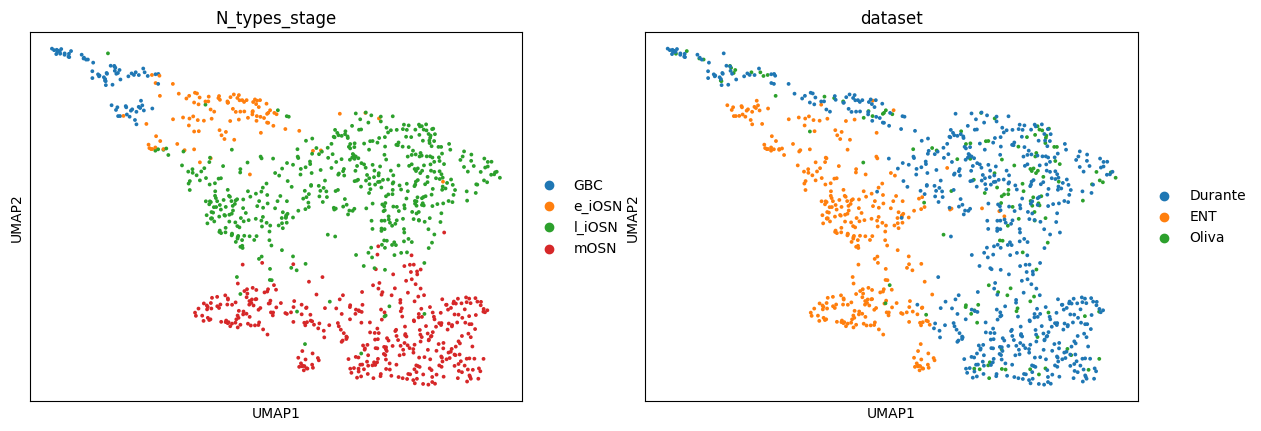

In [475]:
for i in range(1, 11):
    for hvg in [2000,3000]:
        adata1 = scvi_osn(batch='donor_name', n_hvg=hvg, i=i)
        adata1.write(f'./figures/ent_goldstein_scvi_osn_{i}_{hvg}.h5ad')#/sc/arion/projects/roussp01a/liting/Olf

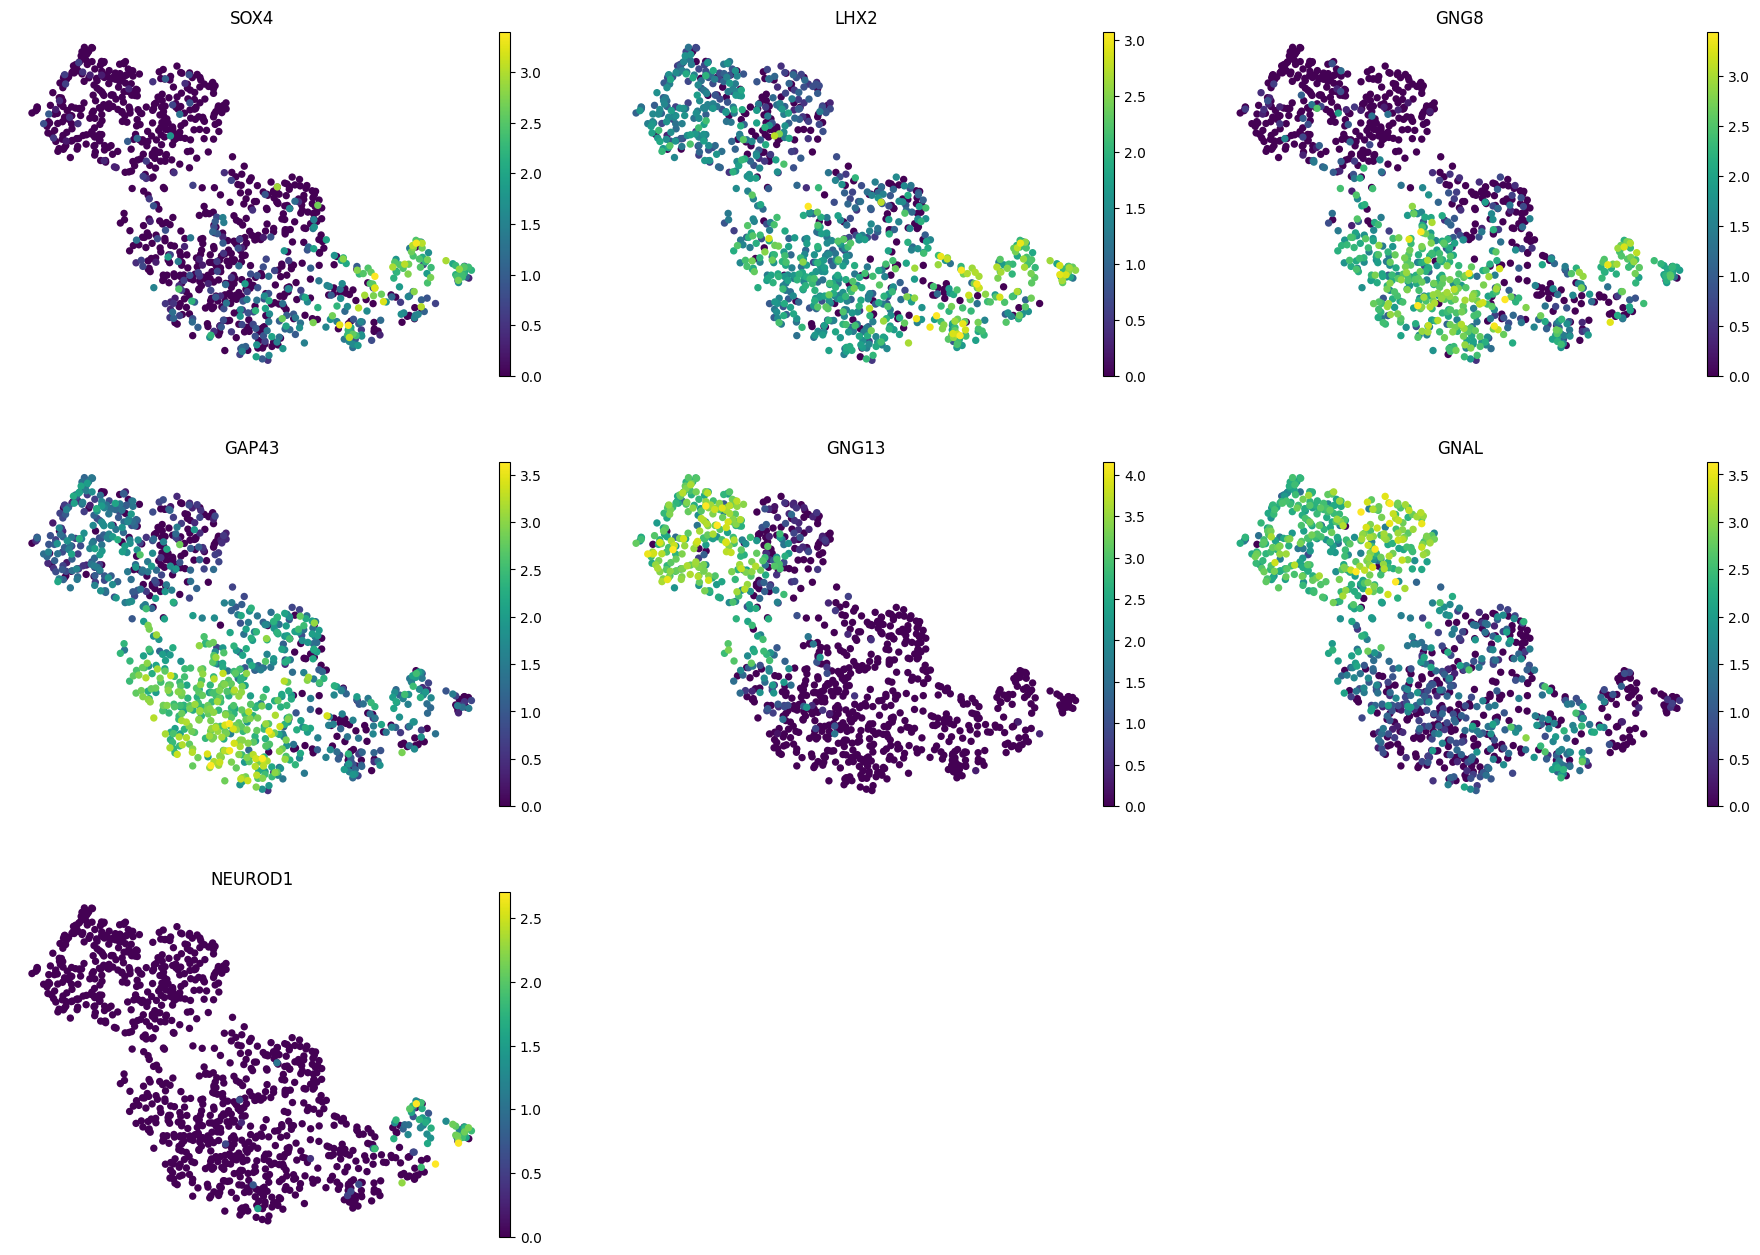

In [458]:

genes = ['SOX4','LHX2','GNG8','GAP43','GNG13','GNAL','NEUROD1']#,''

sc.pl.umap(
    adata1,
    color=genes,
    use_raw=False,
    #cmap="cmo.matter",
    ncols=3,
    frameon=False,
    vmax="p99.9",
    #layer="norm"
)

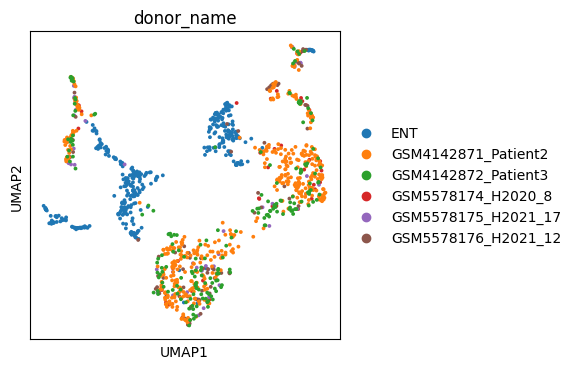

In [390]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(adata1, color="donor_name",  s=30, ax=ax, vmax="p99.99")

In [258]:
# sc.pl.umap(
#     adata,
#     color=["n_genes", "total_counts", "pct_counts_mt", "log1p_total_counts"],
#     cmap="cubehelix_r",
#     s=30,
#     ncols=2,
# )

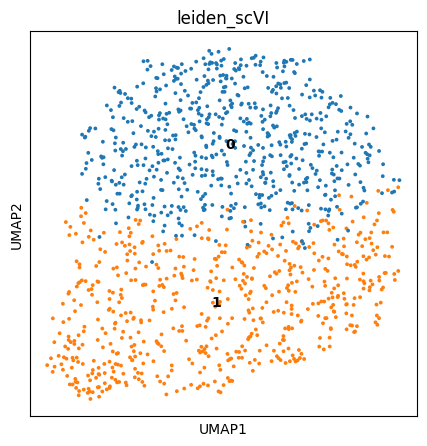

In [259]:
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color="leiden_scVI", legend_loc="on data", ax=ax, s=30)

In [177]:
adata.obs["N_types"] = adata.obs["leiden_scVI"].map(
    {
        
        "1": "iOSN",
        "3": "iOSN",
        "2": "mOSN",
        "4": "GBC",
    }
)

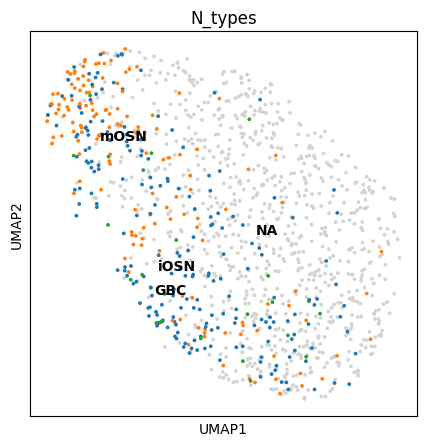

In [242]:
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color="N_types", legend_loc="on data", ax=ax, s=30)

In [243]:
#sc.write(cmc_dir+"qc_scanpy/ent_goldstein_osn_scvi.h5ad", adata)

In [244]:
adata.obs["N_types"]

Set5_C1_AAGCGAGTCAGTCCGG                  iOSN
Set5_C1_AATGACCAGCGTTACT                  iOSN
Set5_C1_AGCGATTGTCGAACGA                  mOSN
Set5_C1_AGGCTGCCAAGGTCTT                  iOSN
Set5_C1_AGGGAGTCAATTGAAG                  iOSN
                                          ... 
TTTACGTTCGCTACAA-1-GSM4142872_Patient3     NaN
TTTCACAGTCCAATCA-1-GSM4142872_Patient3     NaN
TTTCACAGTTGCCAAT-1-GSM4142872_Patient3     NaN
TTTCGATCACTTGAGT-1-GSM4142872_Patient3     NaN
TTTGGAGGTTCGTAAC-1-GSM4142872_Patient3     NaN
Name: N_types, Length: 1238, dtype: category
Categories (3, object): ['iOSN', 'mOSN', 'GBC']

In [245]:
sc.pp.normalize_total(adata, target_sum=2000)
sc.pp.scale(adata)

normalizing counts per cell
    finished (0:00:00)


/hpc/users/songl05/.local/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


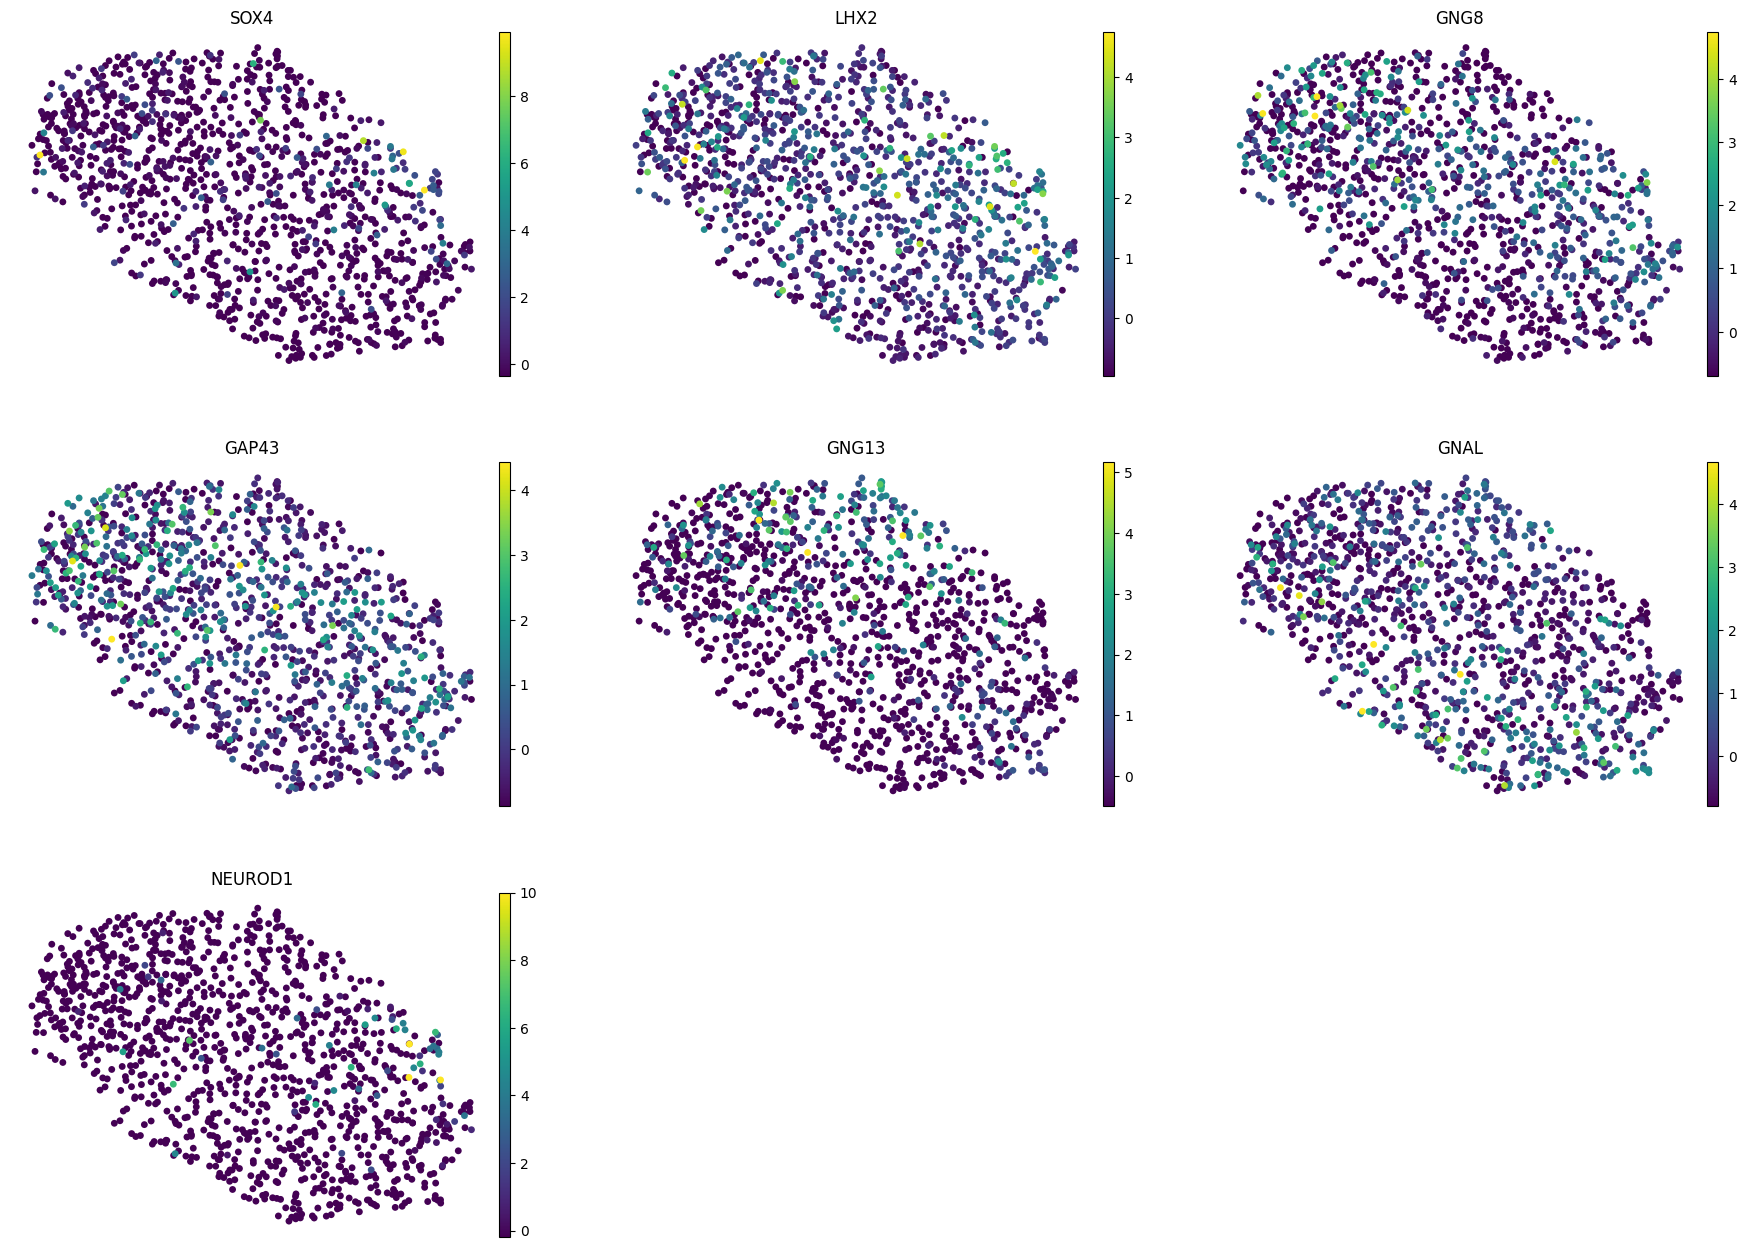

In [270]:

genes = ['SOX4','LHX2','GNG8','GAP43','GNG13','GNAL','NEUROD1']#,''

sc.pl.umap(
    adata,
    color=genes,
    use_raw=False,
    #cmap="cmo.matter",
    ncols=3,
    frameon=False,
    vmax="p99.9",
    #layer="norm"
)

In [196]:
# scvi.model.SCANVI.setup_anndata(
#     adata_query,
#     layer="counts",
#     # batch_key= "batch_donor", 
#     continuous_covariate_keys=['log1p_n_genes_by_counts','total_counts'],
#      #categorical_covariate_keys=['batch_donor'],
#     #continuous_covariate_keys=["log1p_n_genes_by_counts"]
#     batch_key="batch_donor",
#     labels_key="CellType", unlabeled_category="Unknown"
    
# )
#scanvi_model = scvi.model.SCANVI.from_scvi_model(model, unlabeled_category="Unknown")
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    model,
    adata=adata_query,
    unlabeled_category="Unknown",
    labels_key='CellType',
)

scanvi_model.train(max_epochs=50)

SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "C_scANVI"

adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata_query)
adata.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata_query)

ValueError: Making .obs["CellType"] categorical failed. Expected categories: ['Globose Basal Cells' 'Immature Neurons' 'Mature Neurons']. Received categories: Index(['Globose Basal Cells', 'Immature Neurons', 'Mature Neurons'], dtype='object'). 

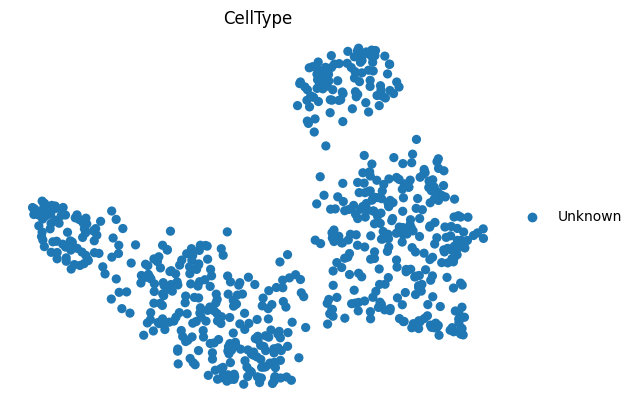

In [2243]:
sc.pl.umap(
    adata,
    color= "CellType",
    frameon=False,
    ncols=1,
   # palette=adata.uns["cell_ontology_class_colors"],
)

KeyError: 'Could not find key C_scANVI in .var_names or .obs.columns.'

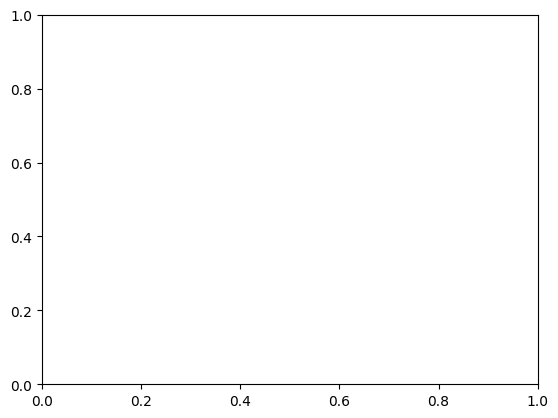

In [2244]:
sc.pl.umap(
    adata,
    color= SCANVI_PREDICTION_KEY,
    frameon=False,
    ncols=1,
   # palette=adata.uns["cell_ontology_class_colors"],
)

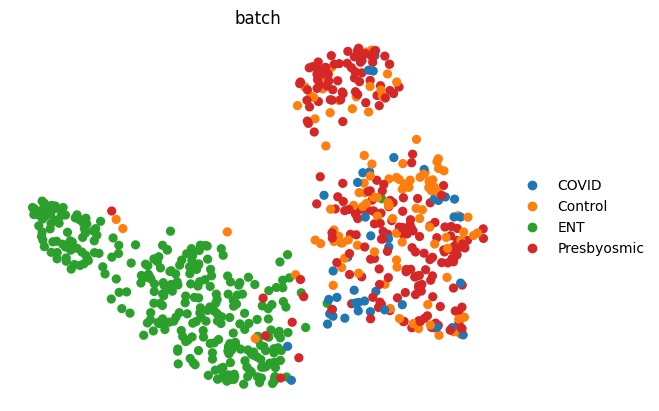

In [2245]:
sc.pl.umap(
    adata,
    color= 'batch',
    frameon=False,
    ncols=1,
   # palette=adata.uns["cell_ontology_class_colors"],
)

# QC analysis

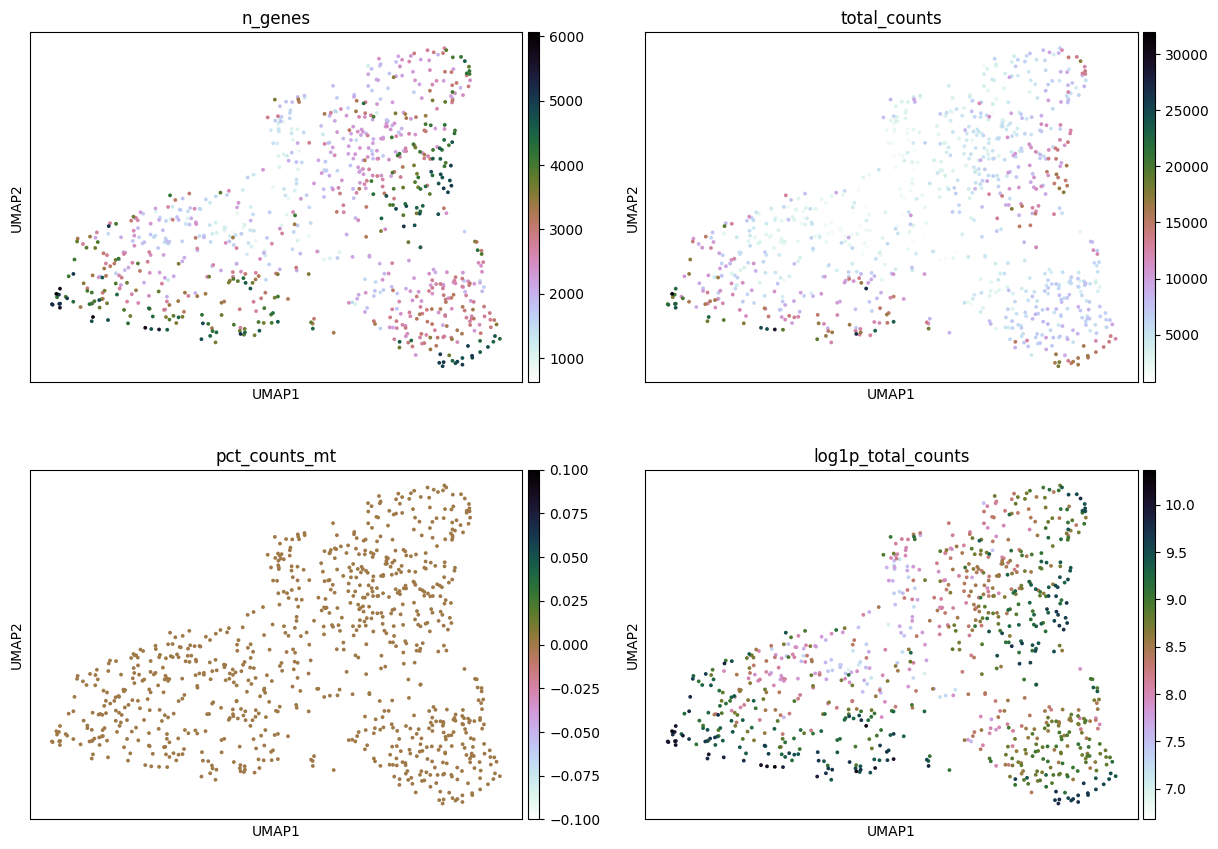

In [2139]:
sc.pl.umap(
    adata,
    color=["n_genes", "total_counts", "pct_counts_mt", "log1p_total_counts"],
    cmap="cubehelix_r",
    s=30,
    ncols=2,
)

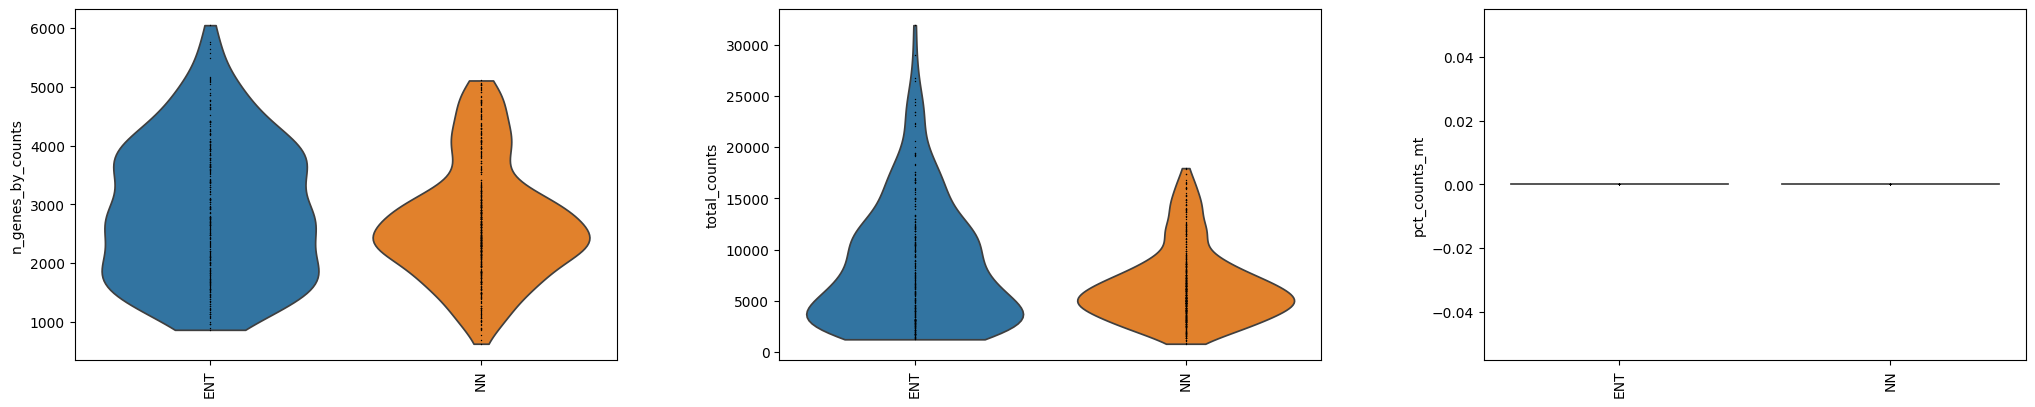

In [2122]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby='batch',
    jitter=False,
    multi_panel=True,
    rotation=90
    #save='1_ENT_violin_qc.pdf'
)

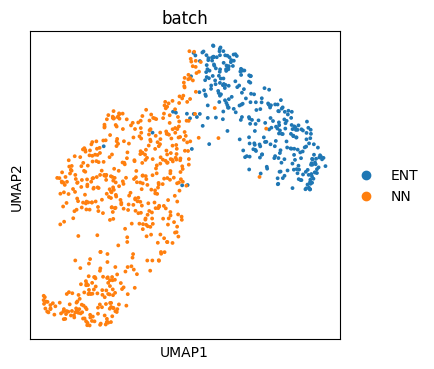

In [2123]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(adata, color=["batch"], s=30, ax=ax, vmax="p99.99")


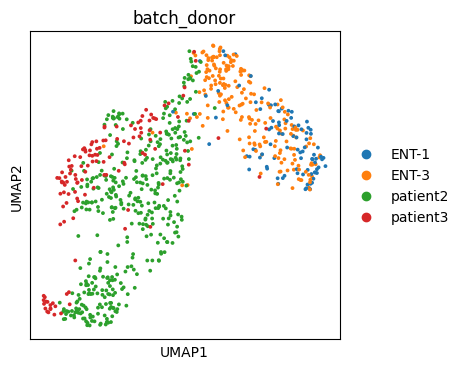

In [2124]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(adata, color="batch_donor", s=30, ax=ax)

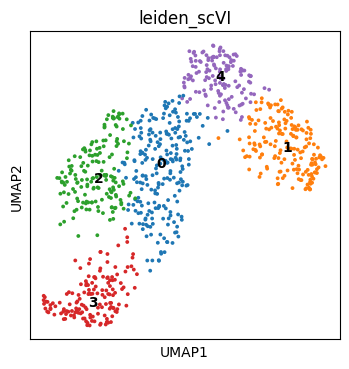

In [2125]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(adata, color="leiden_scVI", legend_loc="on data", ax=ax, s=30)

In [2126]:
#adata.layers["norm"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=None)
#sc.pp.scale(adata)

normalizing counts per cell
    finished (0:00:00)


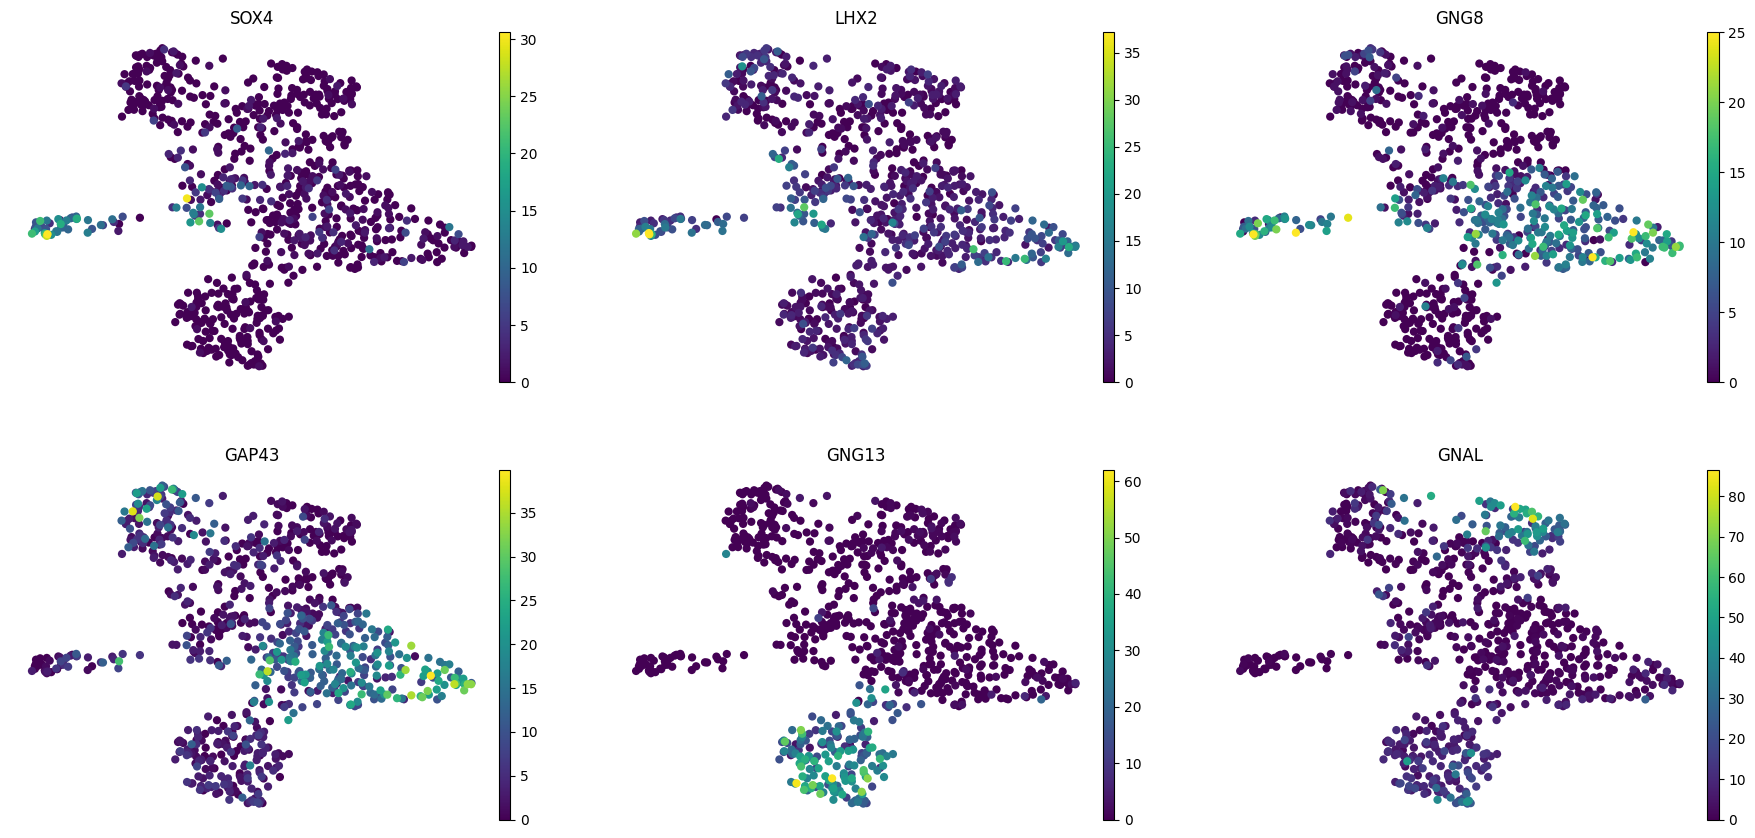

In [2163]:
#Analyze expression of given genes in global UMAP

#For example

genes = ['SOX4','LHX2','GNG8','GAP43','GNG13','GNAL']

sc.pl.umap(
    adata,
    color=genes,
    use_raw=False,
    #cmap="cmo.matter",
    ncols=3,
    frameon=False,
    vmax="p99.9",
    #layer="norm"
)

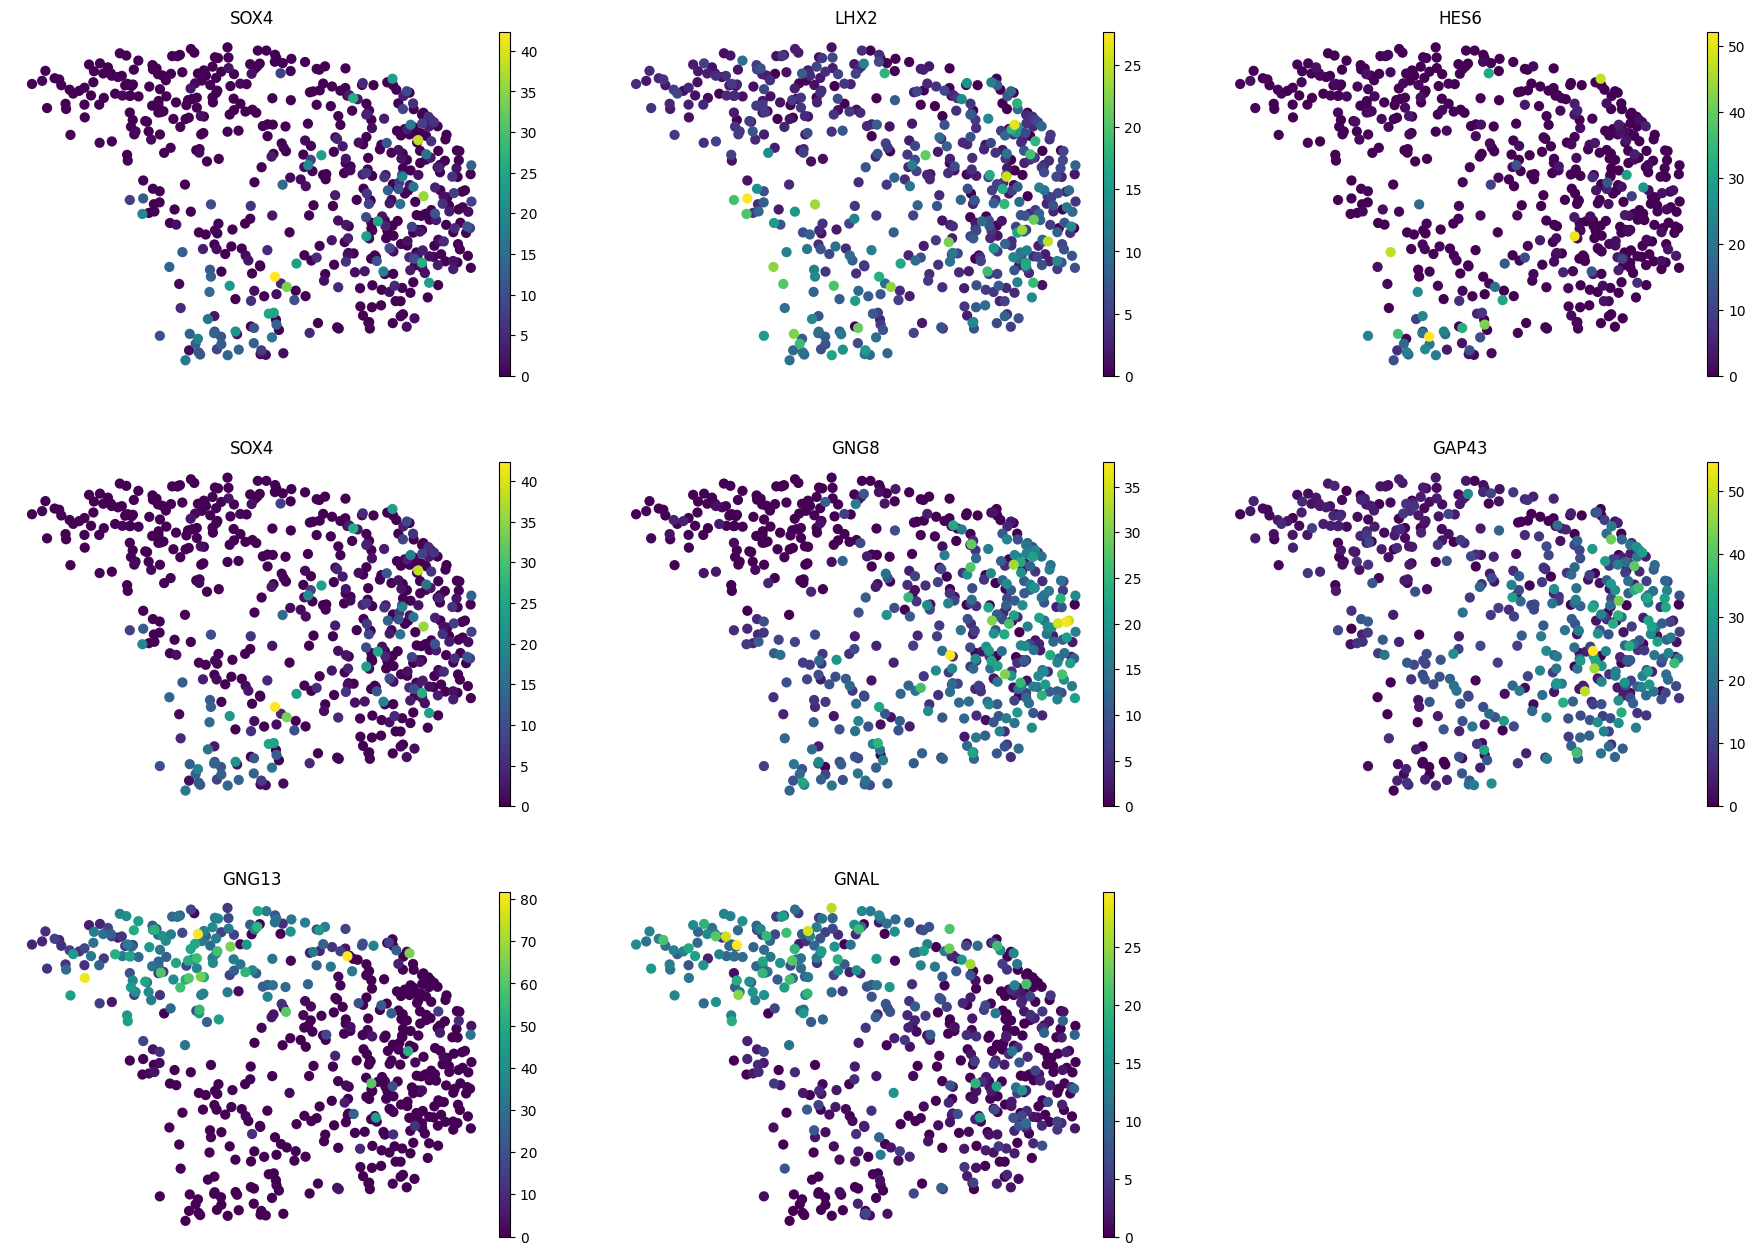

In [2080]:
sc.pl.umap(
    adata[adata.obs.batch=='NN'],
    color=genes,
    use_raw=False,
    #cmap="cmo.matter",
    ncols=3,
    frameon=False,
    vmax="p99.9",
    #layer="norm"
)

In [2024]:
sc.pl.umap(
    adata[adata.obs.batch=='ENT'],
    color=genes,
    use_raw=False,
    #cmap="cmo.matter",
    ncols=3,
    frameon=False,
    vmax="p99.9",
    layer="norm"
)

KeyError: 'norm'

<Figure size 2183.4x1440 with 0 Axes>

In [654]:
leiden_scVI_1.2

SyntaxError: invalid syntax (1648349734.py, line 1)

In [150]:
#adata.obs['cluster'] = adata.obs["leiden_scVI_1.1"].copy()

In [48]:
adata_osn.write('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/stm_adata_osn.h5ad')